# $(SASA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Simple_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
8,8,0,"(0.18, 1.6)","(-0.016, -0.415, 0.047, 0.241)",0,1.0,"(-0.024, -0.601, 0.052, 0.343)",1.0,1.0,"(-0.036, -0.415, 0.059, 0.252)"
93,20,2,"(0.01, 1.0)","(-0.063, -1.151, 0.05, 0.842)",0,1.0,"(-0.086, -1.339, 0.067, 0.986)",1.0,1.0,"(-0.112, -1.152, 0.086, 0.859)"
166,19,5,"(0.43, 0.0)","(0.061, 0.223, -0.012, -0.243)",0,1.0,"(0.065, 0.024, -0.017, 0.138)",1.0,1.0,"(0.066, 0.223, -0.014, -0.255)"
96,23,2,"(0.01, 1.0)","(-0.135, -0.964, 0.104, 0.735)",0,1.0,"(-0.155, -1.153, 0.118, 0.887)",1.0,1.0,"(-0.178, -0.966, 0.136, 0.768)"
235,9,9,"(0.92, 0.9)","(0.089, -0.214, -0.103, 0.264)",0,1.0,"(0.085, -0.412, -0.097, 0.618)",0.0,1.0,"(0.077, -0.61, -0.085, 0.974)"
...,...,...,...,...,...,...,...,...,...,...
42,42,0,"(0.18, 1.6)","(-0.039, 1.054, 0.195, -0.073)",0,1.0,"(-0.018, 0.867, 0.194, 0.042)",0.0,1.0,"(-0.001, 0.68, 0.195, 0.157)"
231,5,9,"(0.92, 0.9)","(0.067, 0.58, -0.051, -1.201)",0,1.0,"(0.079, 0.381, -0.075, -0.819)",0.0,1.0,"(0.086, 0.182, -0.092, -0.45)"
241,15,9,"(0.92, 0.9)","(0.052, -0.205, -0.059, 0.06)",0,1.0,"(0.048, -0.404, -0.058, 0.437)",0.0,1.0,"(0.04, -0.603, -0.049, 0.816)"
139,17,4,"(0.88, 1.8)","(0.097, 0.948, 0.0, -0.874)",1,1.0,"(0.116, 1.138, -0.017, -1.064)",1.0,1.0,"(0.139, 1.329, -0.038, -1.256)"


In [ ]:
model = Base_Line_Simple_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([259, 4])) that is different to the input size (torch.Size([4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


,epoch,mse_s,transition,reward
0,0,"[0.03381679952144623, 0.8369183540344238, 0.23...",1.802947,0.270749
1,1,"[0.03237923979759216, 0.8269275426864624, 0.23...",1.782982,0.270038
2,2,"[0.030990799888968468, 0.817062258720398, 0.22...",1.763399,0.269332
3,3,"[0.029651260003447533, 0.8073196411132812, 0.2...",1.744199,0.268631
4,4,"[0.028360366821289062, 0.7976958155632019, 0.2...",1.725381,0.267936


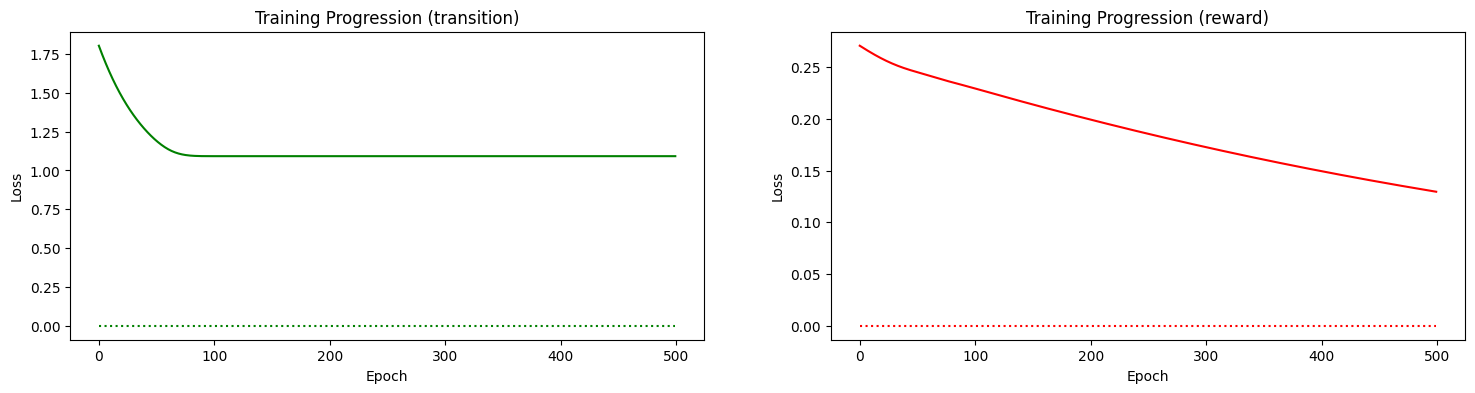

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

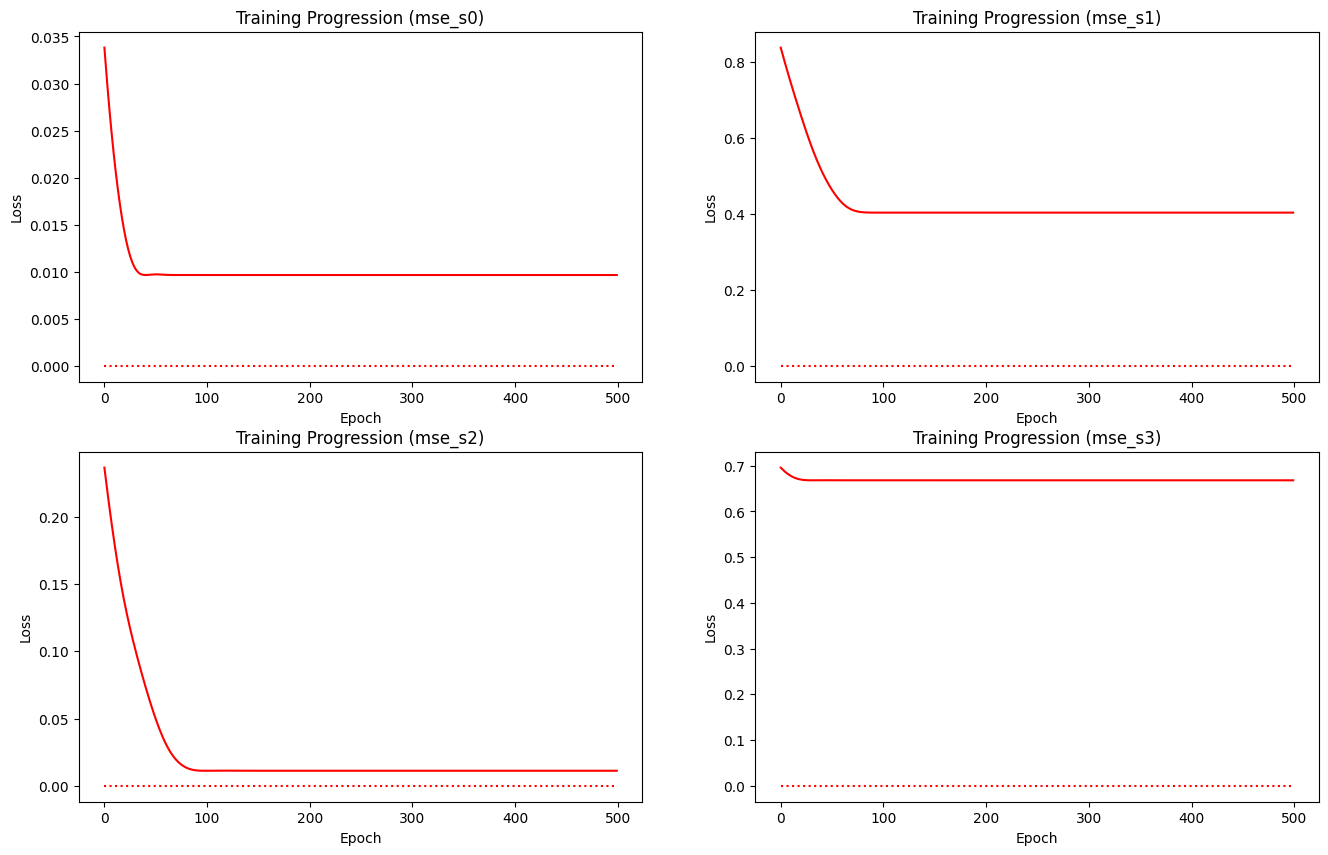

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [6]:
results = data.evaluate_model(model, path='testing_data.csv')
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_r
0,0,0,"(0.49, 0.0)","(0.005, 0.039, -0.028, -0.013)",1,1.0,"(0.006, 0.24, -0.028, -0.434)",1.0,1.0,"(0.011, 0.441, -0.037, -0.856)","(0.026, -0.018, 0.073, -0.219)",0.6
1,1,0,"(0.49, 0.0)","(0.006, 0.24, -0.028, -0.434)",1,1.0,"(0.011, 0.441, -0.037, -0.856)",0.0,1.0,"(0.019, 0.241, -0.054, -0.463)","(0.129, 0.013, 0.213, -0.401)",0.7
2,2,0,"(0.49, 0.0)","(0.011, 0.441, -0.037, -0.856)",0,1.0,"(0.019, 0.241, -0.054, -0.463)",1.0,1.0,"(0.024, 0.442, -0.063, -0.896)","(0.025, -0.023, 0.078, -0.217)",0.6
3,3,0,"(0.49, 0.0)","(0.019, 0.241, -0.054, -0.463)",1,1.0,"(0.024, 0.442, -0.063, -0.896)",1.0,1.0,"(0.033, 0.644, -0.081, -1.331)","(0.057, -0.096, 0.127, -0.259)",0.6
4,4,0,"(0.49, 0.0)","(0.024, 0.442, -0.063, -0.896)",1,1.0,"(0.033, 0.644, -0.081, -1.331)",1.0,1.0,"(0.046, 0.846, -0.108, -1.774)","(0.096, -0.168, 0.187, -0.304)",0.6


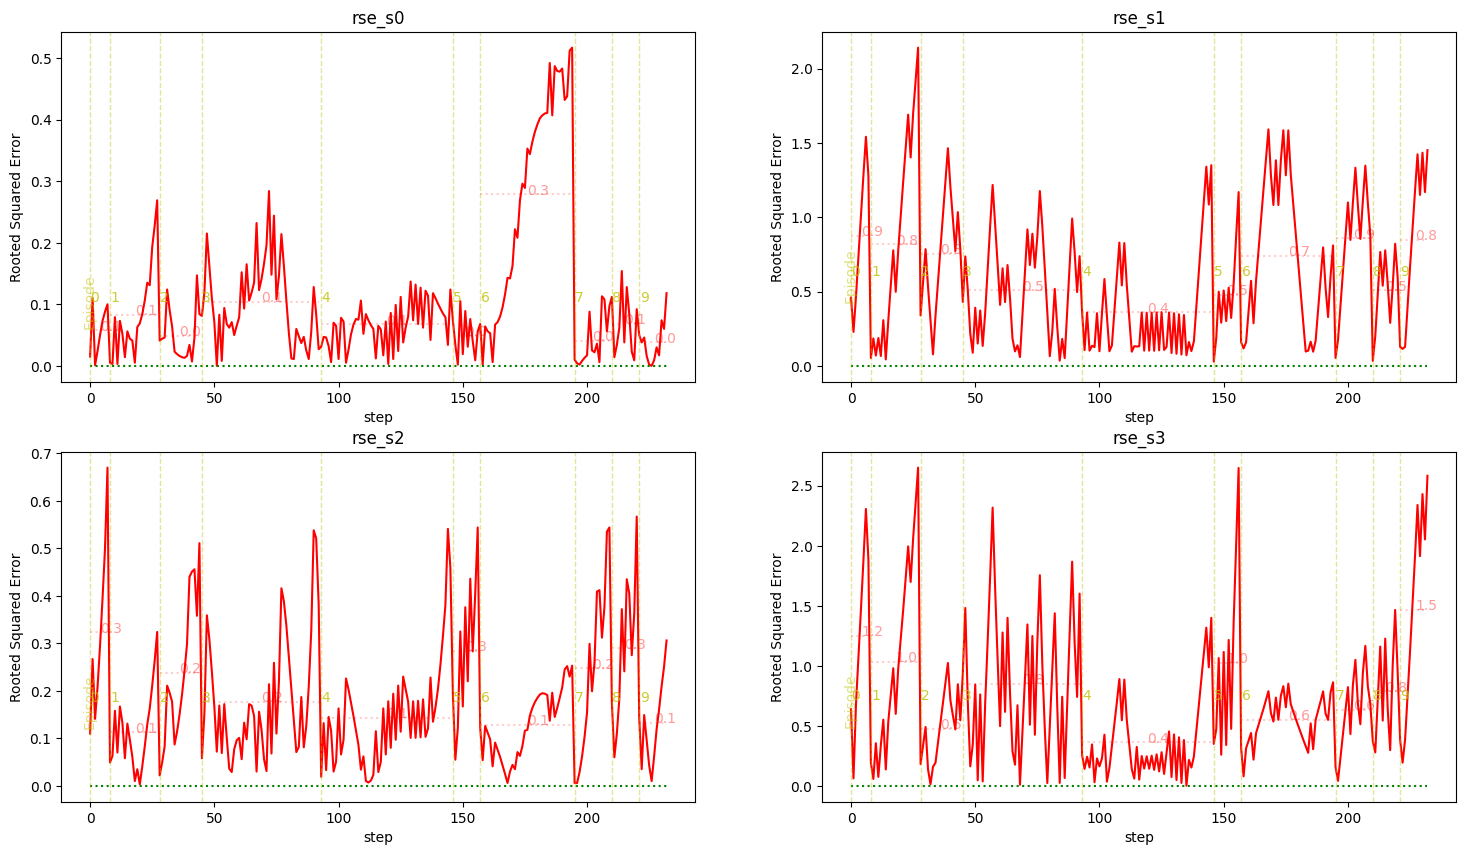

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

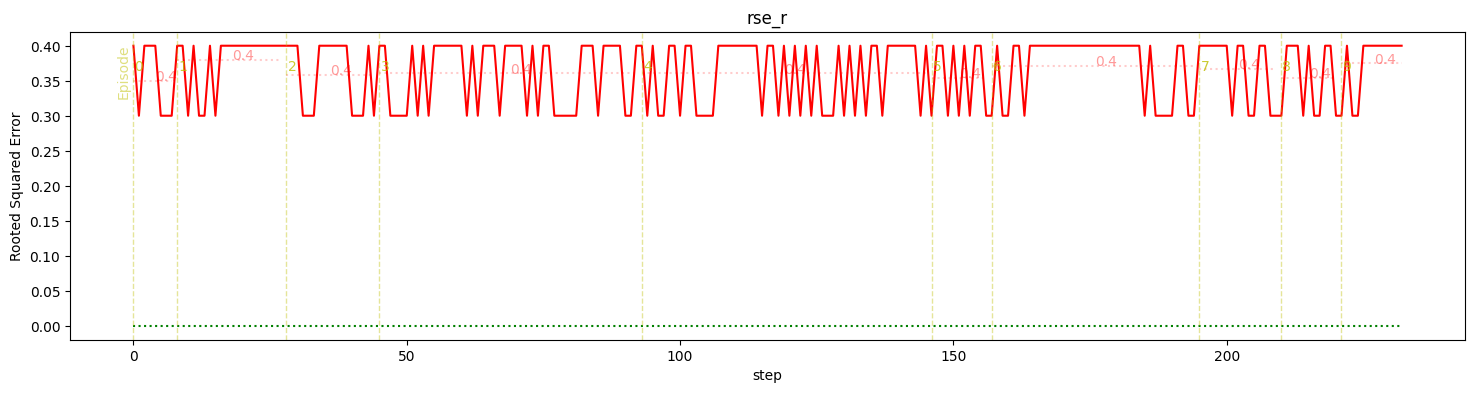

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

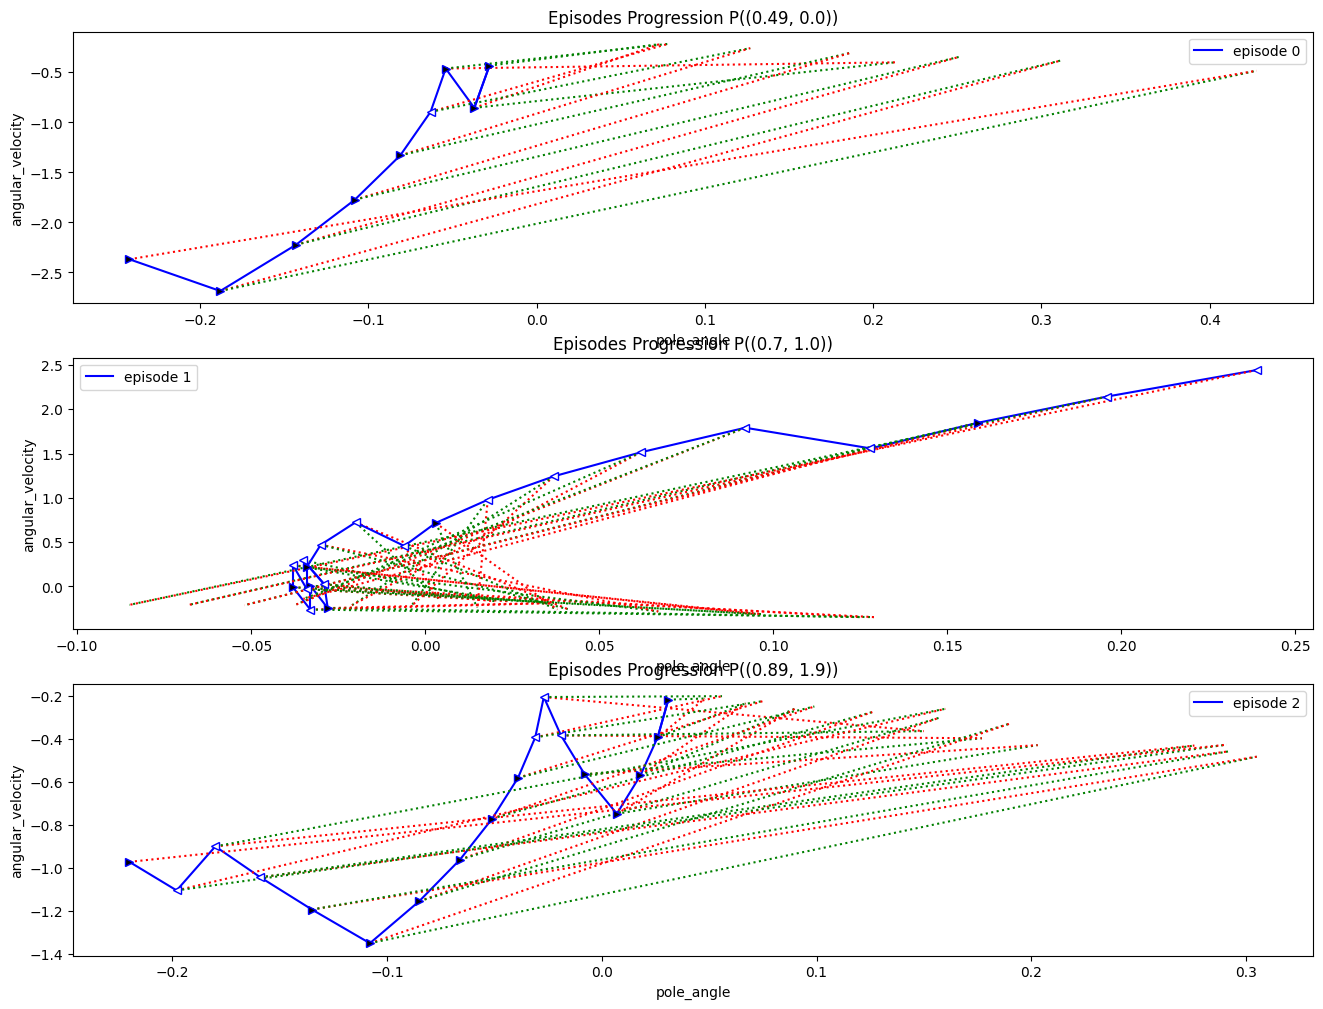

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()